# Generating drift in tabular data

This tutorial shows how to generate drift on pre-existing tabular data and to visualize both the original and the transformed data




In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_iris, make_blobs

from badgers.generators.tabular_data.drift import RandomShiftGenerator, RandomShiftClassesGenerator

## Setup random generator

In [2]:
from numpy.random import default_rng
seed = 0
rng = default_rng(seed)

## Generate data


In [3]:
# load data
X, y = make_blobs(centers=4, random_state=0)
X = pd.DataFrame(data=X, columns=['dimension_0', 'dimension_1'])
y = pd.Series(y)

## Translate each dimension independently

In [4]:
trf = RandomShiftGenerator(random_generator=rng)
Xt, yt = trf.generate(X=X.copy(), y=y, shift_std=np.array([1.,1.]))

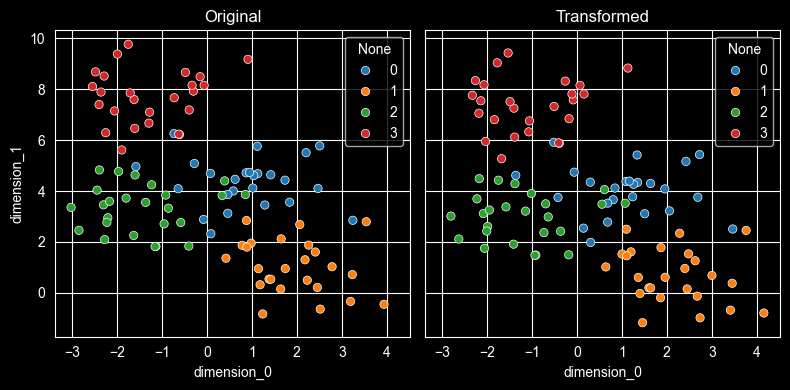

In [5]:
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8,4))
sns.scatterplot(data=X, ax=axes[0], x='dimension_0', y='dimension_1', hue=y, palette=sns.color_palette("tab10")[:4], legend=True)
sns.scatterplot(data=Xt, ax=axes[1], x='dimension_0', y='dimension_1', hue=yt, palette=sns.color_palette("tab10")[:4], legend=True)
axes[0].set_title('Original')
axes[1].set_title('Transformed')
plt.tight_layout()

## Translate each class independently

In [6]:
trf = RandomShiftClassesGenerator(random_generator=rng)
Xt, yt = trf.generate(X=X.copy(), y=y, shift_std=np.array([2.,2.,2.,2.]))

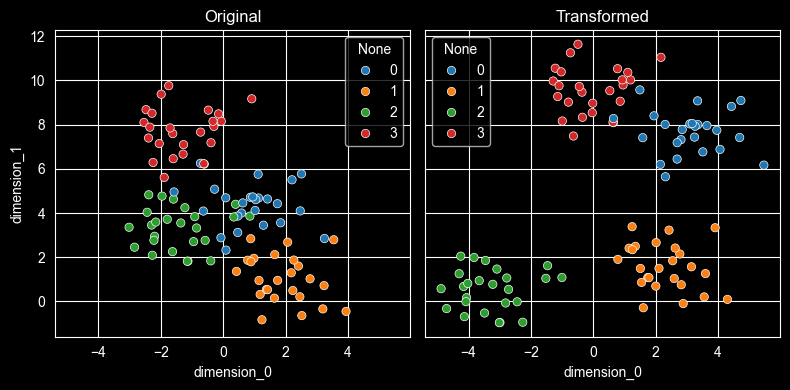

In [7]:
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8,4))
sns.scatterplot(data=X, ax=axes[0], x='dimension_0', y='dimension_1', hue=y, palette=sns.color_palette("tab10")[:4], legend=True)
sns.scatterplot(data=Xt, ax=axes[1], x='dimension_0', y='dimension_1', hue=yt, palette=sns.color_palette("tab10")[:4], legend=True)
axes[0].set_title('Original')
axes[1].set_title('Transformed')
plt.tight_layout()


In [8]:
trf = RandomShiftClassesGenerator(random_generator=rng)
Xt, yt = trf.generate(X=X.copy(), y=y, shift_std=np.array([[1.,4.],[2.,2.],[4.,1.],[0.,0.]]))

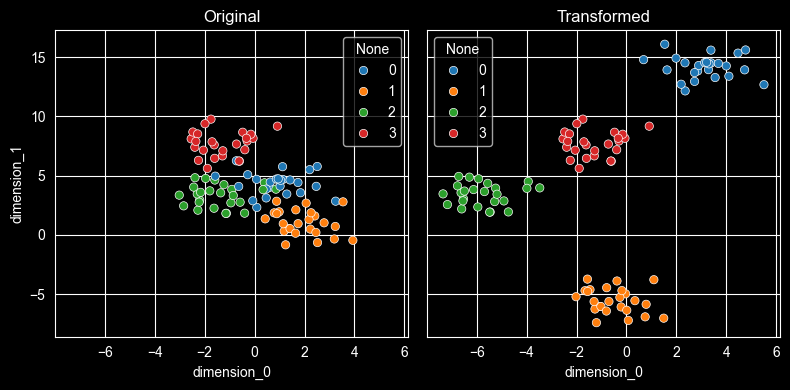

In [9]:
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8,4))
sns.scatterplot(data=X, ax=axes[0], x='dimension_0', y='dimension_1', hue=y, palette=sns.color_palette("tab10")[:4], legend=True)
sns.scatterplot(data=Xt, ax=axes[1], x='dimension_0', y='dimension_1', hue=yt, palette=sns.color_palette("tab10")[:4], legend=True)
axes[0].set_title('Original')
axes[1].set_title('Transformed')
plt.tight_layout()
